비전 트랜스포머(ViT)

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

import pickle

## 이미지 데이터를 파일로 부터 읽어오는 함수
def unpickle(file):
    with open(file,'rb') as ff:
        data = pickle.load(ff, encoding='bytes')
    return data
#--------------------------------------------
## 학습 데이터 만들기
#--------------------------------------------
train_images=[]     #이미지들
train_labels=[]     #이미지이름들

for i in range(1,6):
    batch = unpickle(f"../fff/cifar-10-batches-py/data_batch_{i}")
    train_images.append(batch[b'data'])
    train_labels.extend(batch[b'labels'])
    
    
##5개 파일로 나누어서 들어간 배열들을 붙이기    
## []원소10000 개 배열 * 5  ==> [] 원소 50000 개
train_images=np.concatenate(train_images)    
train_labels=np.array(train_labels)    


#train_images.shape  #(50000, 3072)
## 모양바꾸기 (이미지 형태로 변환)
train_images = train_images.reshape(-1,3,32,32) # (50000, 3, 32, 32)
train_images = np.transpose(train_images,(0,2,3,1)) # (50000, 32, 32, 3)
#train_images.shape



#--------------------------------------------
## 테스트 데이터 만들기
#--------------------------------------------
batch = unpickle(f"../fff/cifar-10-batches-py/test_batch")
test_images=batch[b'data']
test_labels=np.array(batch[b'labels']) 

## 모양바꾸기 (이미지 형태로 변환)
test_images = test_images.reshape(-1,3,32,32) # (10000, 3, 32, 32)
test_images = np.transpose(test_images,(0,2,3,1)) # (10000, 32, 32, 3)
#test_images


#--------------------------------------------
## tensorFlow 형태
#--------------------------------------------
dataset = (
    (train_images, train_labels),
    (test_images, test_labels)
)

print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(50000, 32, 32, 3)
(50000,)
(10000, 32, 32, 3)
(10000,)


In [2]:
## 데이터 정규화 -> ViT 입력형태에 맞춤
train_images = train_images.astype(np.float32) /255.0
test_images = test_images.astype(np.float32) /255.0
num_classes = 10
input_shape = (32,32,3)

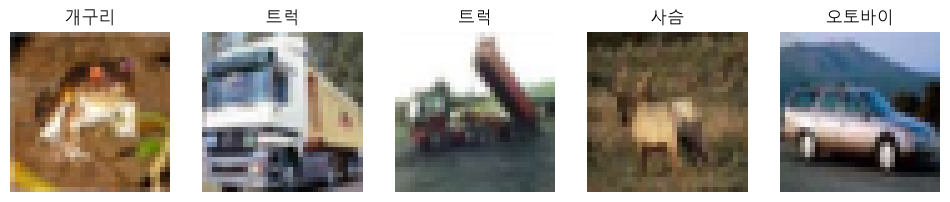

In [3]:
## 중간 이미지 확인
class_names = [
    '비행기', '오토바이', '새','고양이', '사슴', '개', '개구리', '말', '배', '트럭'
]

plt.rc('font', family="Malgun Gothic")
plt.rcParams['axes.unicode_minus']

plt.figure(figsize=(12,3))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(train_images[i])
    
    plt.title(
        class_names[train_labels[i]]
    )
    plt.axis('off')
    
plt.show()

In [4]:
### ViT 하이퍼파라미터
## 이미지를 
image_size = 32    
patch_size=4

## 이미지 32 * 32
## patch 4*4 로 나누기
# patch 조각 : 64개
num_patches = (image_size//patch_size)**2

## 임베딩 차원 : patch를 벡터로 변환
# (작을수록 가볍고 빠름, 크면 성능은 좋음 느림)
#projection_dim = 64
projection_dim = 32

## 여러관점으로 patch 보기
#num_heads = 4
num_heads = 2



## Transformer 내부 MLP 구조 (신경망)
# 64 -> 128 -> 64
transformer_units = [
    projection_dim*2,   #  64 * 2 : 128
    projection_dim      #  64
]


## Transformer Layer : 반복횟수
#transformer_layers = 6
transformer_layers = 4


## Transformer 출력 ->> 최종 분류 Dense
mlp_head_units = [
    256,    ## 특징 확장
    128     #압축
]


In [5]:
## 이미지를 patch 단위로 나누는 layer 클래스
## tf.keras.layers.Layer 상속 받음
class Patchs(tf.keras.layers.Layer):
    def __init__(self, patch_size,**kwargs):
        super().__init__(**kwargs)
        
        self.patch_size = patch_size
        
    def call(self, images):
        # q배치크기
        batch_size = tf.shape(images)[0]
        
        ## 이미지를 patch 로 분할
        
        patches = tf.image.extract_patches(
            images=images,                                      ##원본
            sizes=[1, self.patch_size,self.patch_size,1],       ##patch 크기
            strides=[1, self.patch_size,self.patch_size,1],     ##patch 이동 간격
            rates=[1,1,1,1],                                    ##딜레이 없음
            padding="VALID"                                     ##이미지 마지막까지 patch 생성
        )
        
        patch_dims = patches.shape[-1]          ##patch 마지막 차원 크기
        
        ## 2D 형태 patch => 1D Vector
        patches = tf.reshape(
            patches, [batch_size,-1,patch_dims]
        )
        
        return patches

    def get_config(self):
        config=super().get_config()
        config.update({
            "patch_size":self.patch_size
        })
        return config

In [6]:
### Patch에 의미 부여 하는 layer
## Patch -> Vector 변환,   위치정보 추가
class PatchEncoder(tf.keras.Layer):
    def __init__(self, num_patches, projection_dim,**kwargs):
        super().__init__(**kwargs)
        
        self.num_patches = num_patches
        self.projection_dim=projection_dim
        
        # Patch -> Vector 변환
        self.projection = tf.keras.layers.Dense(projection_dim)
        
        ## 위치정보
        self.position_embedding = tf.keras.layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )
        
    def call(self,patch):
        # 0~ 63 생성
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        
        ## patch + 위치정보
        encoded = (
            self.projection(patch)+self.position_embedding(positions)
        )
        
        return encoded
    
    def get_config(self):
        config=super().get_config()
        config.update({
            "num_patches":self.num_patches,
            "projection_dim":self.projection_dim
        })
        return config
        

In [7]:
## Transformer 내부 Network
def mlp(x, hidden_units, dropout_rate):
    
    for units in hidden_units:
        # Dense Layer
        x = tf.keras.layers.Dense(units,activation=tf.nn.gelu)(x)
        
        ## 과적합 방지
        x = tf.keras.layers.Dropout(dropout_rate)(x)
        
    return x

In [8]:
## ViT 모델 생성(비전 트랜스포머 모델 생성)
### 1. 이미지를 조각(patch)로 나눈다
### 2. 모든 조각이 참고한다
### 3. 기존정보 + 변환결과

def create_vit_classifier():
    ## 입력레이어
    inputs = tf.keras.Input(shape=input_shape)
    
    ## 이미지 -> patch
    ## Patches : 위에서 만든 클래스.call(inputs) 실행
    patches = Patchs(patch_size)(inputs)
    
    # Patch -> Vector 변환,   위치정보 추가
    # PatchEncoder : 위에서 만든 클래스.call(inputs) 실행
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)
    
    
    ## 반복변수 _ ::> 사용하지 않겠다 반복은 하지만 반복변수는 사용하지 않음
    for _ in range(transformer_layers):
        ##  입력 안정화
        x1 = tf.keras.layers.LayerNormalization(
            epsilon=1e-6    # 0 나누기 방지
        )(encoded_patches)
        



        ## Multi-Head Self Attendsion :  모든 patch가 서로 참고 => 각 patch가 다른 patch 참고해서 새롭게 표현
        #Q = Query :현재Patch, K=Key : 모든Patch, V=Value(정보)
        
        attention_output = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,        ## 여러관점 : 4개
            key_dim=projection_dim,     #  head 차원
            dropout=0.1                 # 과적합 방지
        )(x1,x1)        ## Self Attendsion (Q=K=V)
        
        
        
        ## 기본정보 + Attention_output : 정보손실과 gradient 소실 방지
        x2 = tf.keras.layers.Add()([ attention_output , encoded_patches])
        
        ##  입력 안정화
        x3 = tf.keras.layers.LayerNormalization(
            epsilon=1e-6    # 0 나누기 방지
        )(x2)
        
        ## 위에서 정의한 함수 : Transformer 내부 Network
        x3= mlp(
            x3,
            hidden_units=transformer_units,   ## 위에서 정의 : transformer_units = [128,64]
            dropout_rate=0.1
        )
        
        ##  Attention 이전정보, mlp 결과 결합
        encoded_patches = tf.keras.layers.Add()([ x3, x2])
        
    ## 반복문 이후 Transformer 출력정리
    representation = tf.keras.layers.LayerNormalization(
            epsilon=1e-6    # 0 나누기 방지
        )(encoded_patches)
    
    # 64 patches * 64 dim ==> 1차원 백터로 변환
    #representation = tf.keras.layers.Flatten()(representation )
    representation = tf.keras.layers.GlobalAveragePooling1D()(  # GlobalAveragePooling1D
        representation
    )
    
    
    ## 뉴런 랜덤 제거 ==> 과적합 방지  50% 제거
    representation = tf.keras.layers.Dropout(0.5)(representation)
    
    ##구조 256 -> 128 
    features = mlp(
        representation,
        hidden_units=mlp_head_units,  # mlp_head_units = [  256,  128  ]
        dropout_rate=0.5
    )
    
    ##출력층  :: 출력 결과 클래스 10개
    logits = tf.keras.layers.Dense(num_classes)(features)
    
    ## 모델 생성 및 리턴
    ## 입력-> 출력 Keras 모델 생성
    return tf.keras.Model(
        inputs=inputs,
        outputs=logits
    )
        

In [9]:
## 모델 생성
vit = create_vit_classifier()

##모델 구조 출력
vit.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patchs (Patchs)     │ (None, None, 48)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 64, 32)    │      3,616 │ patchs[0][0]      │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 32)    │         64 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 32)    │      8,416 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 32)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 32)    │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 32)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 32)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 32)    │      8,416 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 32)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 64)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 32)    │      2,080 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 97,258 (379.91 KB)

 Trainable params: 97,258 (379.91 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
## 경사하강법
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-4
)

In [11]:
vit.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top-5-accuracy"
        )
    ]
)

In [12]:
## 학습
history = vit.fit(
    train_images,
    train_labels,
    batch_size=128, # 1번에 128 개씩 묶어서 학습
    epochs=50,      # 반복횟수 50
    validation_split=0.1    #데이터의 10% 검증용으로 자동분리
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - accuracy: 0.2025 - loss: 2.1027 - top-5-accuracy: 0.7281 - val_accuracy: 0.3158 - val_loss: 1.8104 - val_top-5-accuracy: 0.8578
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.2832 - loss: 1.8631 - top-5-accuracy: 0.8445 - val_accuracy: 0.3616 - val_loss: 1.6689 - val_top-5-accuracy: 0.8904
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.3230 - loss: 1.7697 - top-5-accuracy: 0.8673 - val_accuracy: 0.3924 - val_loss: 1.5923 - val_top-5-accuracy: 0.9034
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - accuracy: 0.3584 - loss: 1.6998 - top-5-accuracy: 0.8817 - val_accuracy: 0.4188 - val_loss: 1.5283 - val_top-5-accuracy: 0.9130
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 78ms/step - accuracy: 0.3900 - loss: 1.6298 - top-5-accuracy: 0.8976 - val_accuracy: 0.4456 - val_loss: 1.4576 - val_top-5-accuracy: 0.9288
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.4161 - loss:

In [13]:
## 모델 저장 (학습 끝난 직후)
vit.save_weights("vit.weights.h5")

In [14]:
## 학습된 모델 평가
res = vit.evaluate(
    test_images,
    test_labels
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6060 - loss: 1.1260 - top-5-accuracy: 0.9627


In [15]:
## 저장한 모델 로드하여 실행 - 학습이 없음

#1. 모델구조 생성
vit2 = create_vit_classifier()

#2. 모델 가중치 불러오기
vit2.load_weights("vit.weights.h5")

#3. complile
optimizer2 = tf.keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-4
)

vit2.compile(
    optimizer=optimizer2,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top-5-accuracy"
        )
    ]
)


#4.평가
vit2.evaluate(test_images, test_labels)


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6060 - loss: 1.1260 - top-5-accuracy: 0.9627


[1.125971794128418, 0.6060000061988831, 0.9627000093460083]

In [16]:
## 저장한 가중치로 예측
pred = vit2.predict(test_images)
#print(pred.shape)  (10000, 10)

pred_labels = np.argmax(pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step


In [17]:
for i in range(10):
    print(f"실제: {class_names[test_labels[i]]}, 예측: {class_names[pred_labels[i]]}")

실제: 고양이, 예측: 고양이
실제: 배, 예측: 배
실제: 배, 예측: 배
실제: 비행기, 예측: 비행기
실제: 개구리, 예측: 개구리
실제: 개구리, 예측: 개구리
실제: 오토바이, 예측: 오토바이
실제: 개구리, 예측: 개구리
실제: 고양이, 예측: 개
실제: 오토바이, 예측: 오토바이


In [18]:
## 저장한 가중치로 예측
pred = vit.predict(test_images)
#print(pred.shape)  (10000, 10)

pred_labels = np.argmax(pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step


In [19]:
for i in range(10):
    print(f"실제: {class_names[test_labels[i]]}, 예측: {class_names[pred_labels[i]]}")

실제: 고양이, 예측: 고양이
실제: 배, 예측: 배
실제: 배, 예측: 배
실제: 비행기, 예측: 비행기
실제: 개구리, 예측: 개구리
실제: 개구리, 예측: 개구리
실제: 오토바이, 예측: 오토바이
실제: 개구리, 예측: 개구리
실제: 고양이, 예측: 개
실제: 오토바이, 예측: 오토바이
